In [6]:
# Setup: config + imports
import glob
import os
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import AutoMinorLocator

# Config
CROP_OUT_DIR = "../Data/AIRS-cropped"
VARNAME      = "co_mmr_midtrop"
MW_RATIO     = 28.01 / 44.01          # CO / CO2 molar-mass conversion
OUT_DIR      = "../Figures"
os.makedirs(OUT_DIR, exist_ok=True)

# Balanced window: 23 whole years
START_TS = pd.Timestamp("2003-01-01")
END_TS   = pd.Timestamp("2025-12-01")

## Interpolation to fill gaps in the data (2 months)

In [7]:
# Build gap-free monthly maps over the window, then the spatial-mean series.
crop_files = sorted(glob.glob(os.path.join(CROP_OUT_DIR, "*.nc")))
print(f"Found {len(crop_files)} cropped files")

# Load each month's (lat, lon) map: mean over orbit passes, ratio-corrected.
obs_maps = {}
lons = lats = None
for f in crop_files:
    stem = os.path.splitext(os.path.basename(f))[0]
    date = pd.Timestamp(f"{stem[:4]}-{stem[4:]}-01")
    if not (START_TS <= date <= END_TS):
        continue
    ds_g = xr.open_dataset(f, decode_timedelta=False)
    if lons is None:
        lons = ds_g["lon"].values
        lats = ds_g["lat"].values
    obs_maps[date] = ds_g[VARNAME].mean(dim="orbit_pass", skipna=True).values * MW_RATIO
    ds_g.close()

n_lat, n_lon = len(lats), len(lons)

# Full monthly calendar over the window.
months = pd.date_range(START_TS, END_TS, freq="MS")

# Stack into a (time, lat, lon) cube; missing months stay all-NaN.
raw_maps = np.full((len(months), n_lat, n_lon), np.nan)
has_obs = np.zeros(len(months), dtype=bool)
for i, d in enumerate(months):
    if d in obs_maps:
        raw_maps[i] = obs_maps[d]
        has_obs[i] = True
is_interp = ~has_obs

# Interpolate maps in time, per pixel, to fill missing months.
final_maps = xr.DataArray(
    raw_maps, dims=("time", "lat", "lon"),
    coords={"time": months, "lat": lats, "lon": lons},
)
final_maps = (final_maps.interpolate_na(dim="time", method="linear")
                        .bfill("time").ffill("time"))

# Time series = spatial mean of each map.
ts_dates = months
ts_co    = final_maps.mean(dim=("lat", "lon"), skipna=True).values

# Diagnostics.
n_pix = n_lat * n_lon
filled_dates = [d.strftime('%Y-%m') for d in months[is_interp]]
print(f"Calendar months   : {len(months)}   ({START_TS:%b %Y} - {END_TS:%b %Y})")
print(f"Observed maps      : {has_obs.sum()}")
print(f"Reconstructed maps : {is_interp.sum()}  -> {filled_dates}")
print(f"Grid per map       : {n_lat} lat x {n_lon} lon = {n_pix} pixels")
for i in np.where(is_interp)[0]:
    n_valid_orig = int(np.isfinite(raw_maps[i]).sum())
    n_valid_new  = int(np.isfinite(final_maps.values[i]).sum())
    print(f"   {months[i].strftime('%Y-%m')}: filled {n_valid_new - n_valid_orig} "
          f"pixels  ->  map mean = {ts_co[i]:.4e} kg/kg")

n_dead = int(np.isnan(final_maps.values).all(axis=0).sum())
print(f"Pixels never observed (left NaN): {n_dead}")
print(f"Date range : {ts_dates[0].date()}  ->  {ts_dates[-1].date()}")
print(f"CO range   : {np.nanmin(ts_co):.4e} - {np.nanmax(ts_co):.4e}  kg/kg")

Found 279 cropped files
Calendar months   : 276   (Jan 2003 - Dec 2025)
Observed maps      : 274
Reconstructed maps : 2  -> ['2023-09', '2025-12']
Grid per map       : 36 lat x 61 lon = 2196 pixels
   2023-09: filled 2196 pixels  ->  map mean = 8.5295e-08 kg/kg
   2025-12: filled 2196 pixels  ->  map mean = 7.6991e-08 kg/kg
Pixels never observed (left NaN): 0
Date range : 2003-01-01  ->  2025-12-01
CO range   : 7.6991e-08 - 1.1788e-07  kg/kg


## Mean and SD maps

Stack shape : (276, 36, 61)   (2003-01 - 2025-12)
Mean range  : 8.1518e-08 - 9.8430e-08  kg/kg
Std  range  : 4.7193e-09 - 1.5843e-08  kg/kg


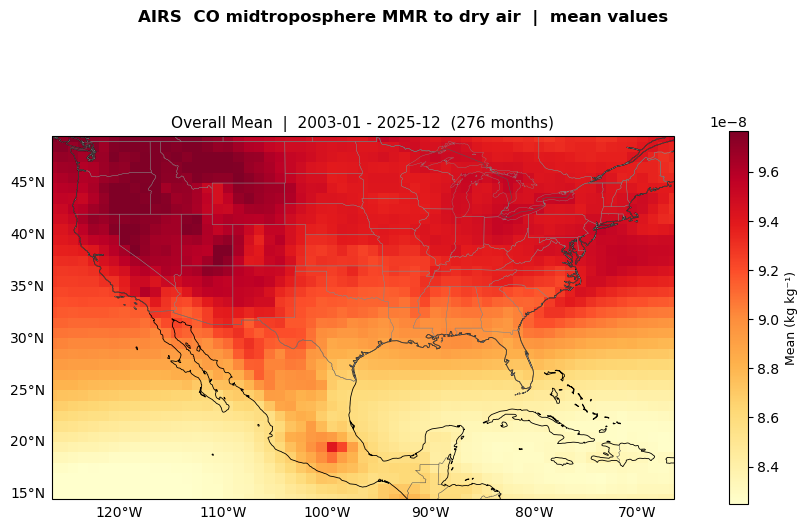

Saved -> ../Figures\co_mmr_midtrop_mean_2003_2025.png


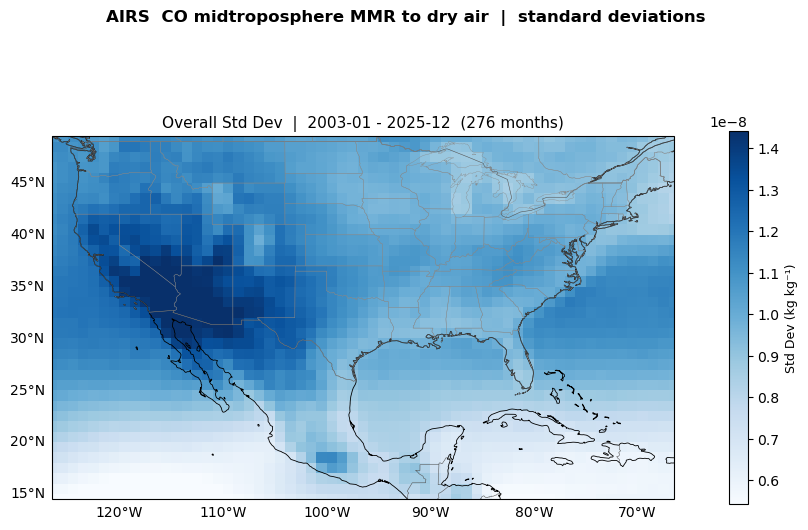

Saved -> ../Figures\co_mmr_midtrop_std_2003_2025.png


In [8]:
# Pixel-wise mean & std across all months of the gap-free cube.
import cartopy.crs as ccrs
import cartopy.feature as cfeature

FIG_DIR = r"../Figures"
os.makedirs(FIG_DIR, exist_ok=True)

stack   = final_maps.values
co_mean = np.nanmean(stack, axis=0)
co_std  = np.nanstd (stack, axis=0, ddof=1)

n_months    = stack.shape[0]
label_first = months[0].strftime("%Y-%m")
label_last  = months[-1].strftime("%Y-%m")

print(f"Stack shape : {stack.shape}   ({label_first} - {label_last})")
print(f"Mean range  : {np.nanmin(co_mean):.4e} - {np.nanmax(co_mean):.4e}  kg/kg")
print(f"Std  range  : {np.nanmin(co_std ):.4e} - {np.nanmax(co_std ):.4e}  kg/kg")

# Map extent from data coords.
lon_min, lon_max = float(lons.min()), float(lons.max())
lat_min, lat_max = float(lats.min()), float(lats.max())


def draw_map(fig, ax, data, cmap, label, title):
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="k")
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor="#555")
    ax.add_feature(cfeature.STATES,    linewidth=0.25, edgecolor="#888")

    pcm = ax.pcolormesh(
        lons, lats, data,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=np.nanpercentile(data, 2), vmax=np.nanpercentile(data, 98),
        shading="nearest",
    )
    gl = ax.gridlines(draw_labels=True, linewidth=0, color="none")
    gl.top_labels = gl.right_labels = False

    cb = fig.colorbar(pcm, ax=ax, orientation="vertical", fraction=0.03, pad=0.06)
    cb.set_label(label, fontsize=9)
    ax.set_title(title, fontsize=11, pad=6)


# Mean map.
fig_mean, ax_mean = plt.subplots(
    figsize=(8, 6), subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)
draw_map(fig_mean, ax_mean, co_mean, plt.cm.YlOrRd,
         "Mean (kg kg⁻¹)",
         f"Overall Mean  |  {label_first} - {label_last}  ({n_months} months)")
fig_mean.suptitle(
    "AIRS  CO midtroposphere MMR to dry air  |  mean values ",
    fontsize=12, fontweight="bold",
)
out_mean = os.path.join(FIG_DIR, "co_mmr_midtrop_mean_2003_2025.png")
fig_mean.savefig(out_mean, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_mean)

# Std-dev map.
fig_std, ax_std = plt.subplots(
    figsize=(8, 6), subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)
draw_map(fig_std, ax_std, co_std, plt.cm.Blues,
         "Std Dev (kg kg⁻¹)",
         f"Overall Std Dev  |  {label_first} - {label_last}  ({n_months} months)")
fig_std.suptitle(
    "AIRS  CO midtroposphere MMR to dry air  |  standard deviations",
    fontsize=12, fontweight="bold",
)
out_std = os.path.join(FIG_DIR, "co_mmr_midtrop_std_2003_2025.png")
fig_std.savefig(out_std, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_std)

## Per-pixel linear fit using ordinary least squares 

In [9]:
# per-pixel linear fit in time
yr = np.arange(len(months)) / 12.0     #decimal years 

Y    = final_maps.values
yr_c = yr - yr.mean()
pixel_slope     = np.tensordot(yr_c, Y - Y.mean(axis=0, keepdims=True),
                               axes=(0, 0)) / np.sum(yr_c**2)   # (lat, lon) kg/kg/yr
pixel_intercept = Y.mean(axis=0) - pixel_slope * yr.mean()      # (lat, lon)

dead = np.all(np.isnan(Y), axis=0)
pixel_slope[dead]     = np.nan
pixel_intercept[dead] = np.nan

# Fitted trend line and residual (detrended) fields.
trend_field = xr.DataArray(
    pixel_intercept[None] + pixel_slope[None] * yr[:, None, None],
    dims=("time", "lat", "lon"), coords=final_maps.coords,
)
detr_field = (final_maps - trend_field).transpose("time", "lat", "lon")

print(f"Per-pixel fit : slope {np.nanmin(pixel_slope):.3e} - {np.nanmax(pixel_slope):.3e} kg/kg/yr")

Per-pixel fit : slope -8.606e-10 - -1.188e-10 kg/kg/yr


In [10]:
# Save detr_field to disk 
detr_field.to_netcdf("detr_field.nc")

## Plot of slopes at each grid point

Per-pixel slope grid : (36, 61)  (lat x lon)
Slope range          : -8.606e-10 - -1.188e-10  kg/kg/yr
Domain-mean slope    : -4.734e-10  kg/kg/yr


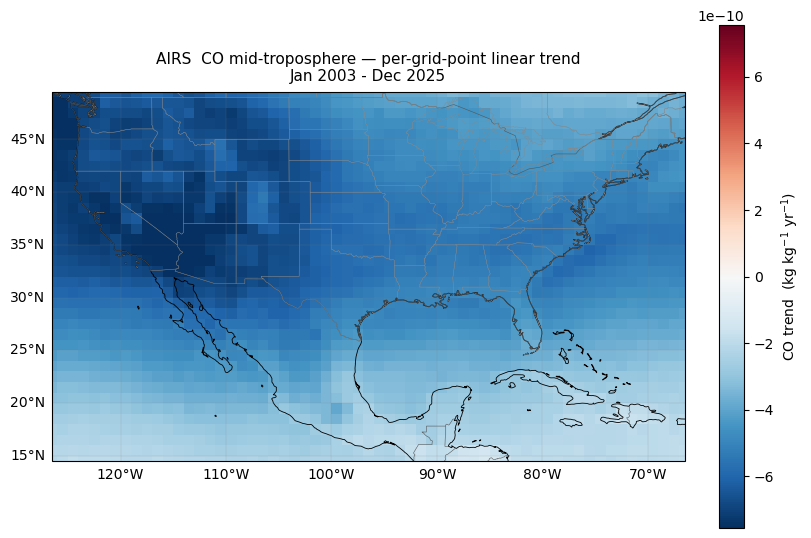

Saved -> ../Figures\spatial_co_trend_slope_2003_2025.png


In [11]:
# Per-pixel slope map from the single fit.
import cartopy.crs as ccrs
import cartopy.feature as cfeature

slope = pixel_slope

print(f"Per-pixel slope grid : {slope.shape}  (lat x lon)")
print(f"Slope range          : {np.nanmin(slope):.3e} - {np.nanmax(slope):.3e}  kg/kg/yr")
print(f"Domain-mean slope    : {np.nanmean(slope):.3e}  kg/kg/yr")

# Plot.
ext = [float(lons.min()), float(lons.max()),
       float(lats.min()), float(lats.max())]

vmax_s = np.nanpercentile(np.abs(slope), 98)

fig_s, ax_s = plt.subplots(
    figsize=(8, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)
ax_s.set_extent(ext, crs=ccrs.PlateCarree())
ax_s.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="k")
ax_s.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor="#555")
ax_s.add_feature(cfeature.STATES,    linewidth=0.25, edgecolor="#888")

pcm = ax_s.pcolormesh(
    lons, lats, slope,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r", vmin=-vmax_s, vmax=vmax_s, shading="auto",
)
cb = fig_s.colorbar(pcm, ax=ax_s, orientation="vertical", shrink=0.85, pad=0.02)
cb.set_label("CO trend  (kg kg$^{-1}$ yr$^{-1}$)", fontsize=10)

gl = ax_s.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4)
gl.top_labels = gl.right_labels = False

ax_s.set_title(
    "AIRS  CO mid-troposphere — per-grid-point linear trend\n"
    f"{months[0].strftime('%b %Y')} - {months[-1].strftime('%b %Y')}",
    fontsize=11, pad=8,
)

out_s = os.path.join(OUT_DIR, "spatial_co_trend_slope_2003_2025.png")
fig_s.savefig(out_s, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_s)

Better plot for above:

Per-pixel slope grid : (36, 61)  (lat x lon)
Abs slope range      : 1.188e-10 - 8.606e-10  kg/kg/yr
Domain-mean abs slope: 4.734e-10  kg/kg/yr


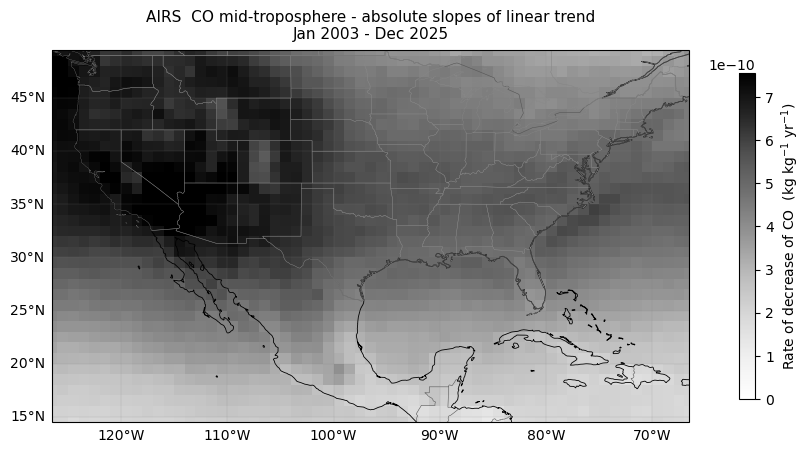

Saved -> ../Figures\spatial_co_trend_slope_2003_2025.png


In [12]:
# Compute absolute values of slope
abs_slope = np.abs(pixel_slope)

print(f"Per-pixel slope grid : {abs_slope.shape}  (lat x lon)")
print(f"Abs slope range      : {np.nanmin(abs_slope):.3e} - {np.nanmax(abs_slope):.3e}  kg/kg/yr")
print(f"Domain-mean abs slope: {np.nanmean(abs_slope):.3e}  kg/kg/yr")

# Map extent
ext = [float(lons.min()), float(lons.max()),
       float(lats.min()), float(lats.max())]

# 2. Set upper bound from 0 to max (98th percentile for robust scaling)
vmax_s = np.nanpercentile(abs_slope, 98)

fig_s, ax_s = plt.subplots(
    figsize=(8, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)
ax_s.set_extent(ext, crs=ccrs.PlateCarree())
ax_s.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="k")
ax_s.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor="#555")
ax_s.add_feature(cfeature.STATES,    linewidth=0.25, edgecolor="#888")

# 3. Plot using 'Greys' colormap (white-gray-black) from vmin=0 to vmax=vmax_s
pcm = ax_s.pcolormesh(
    lons, lats, abs_slope,
    transform=ccrs.PlateCarree(),
    cmap="Greys", vmin=0, vmax=vmax_s, shading="auto",
)

# Reduced shrink from 0.85 to 0.55 so the height is distinctly smaller than the map
cb = fig_s.colorbar(pcm, ax=ax_s, orientation="vertical", shrink=0.55, pad=0.03)
cb.set_label("Rate of decrease of CO  (kg kg$^{-1}$ yr$^{-1}$)", fontsize=10)

gl = ax_s.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4)
gl.top_labels = gl.right_labels = False

ax_s.set_title(
    "AIRS  CO mid-troposphere - absolute slopes of linear trend\n"
    f"{months[0].strftime('%b %Y')} - {months[-1].strftime('%b %Y')}",
    fontsize=11, pad=8,
)

out_s = os.path.join(OUT_DIR, "spatial_co_trend_slope_2003_2025.png")
fig_s.savefig(out_s, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_s)

Per-pixel slope grid : (36, 61)  (lat x lon)
Slope range          : 8.376e-08 - 1.068e-07  kg/kg/yr
Domain-mean slope    : 9.576e-08  kg/kg/yr


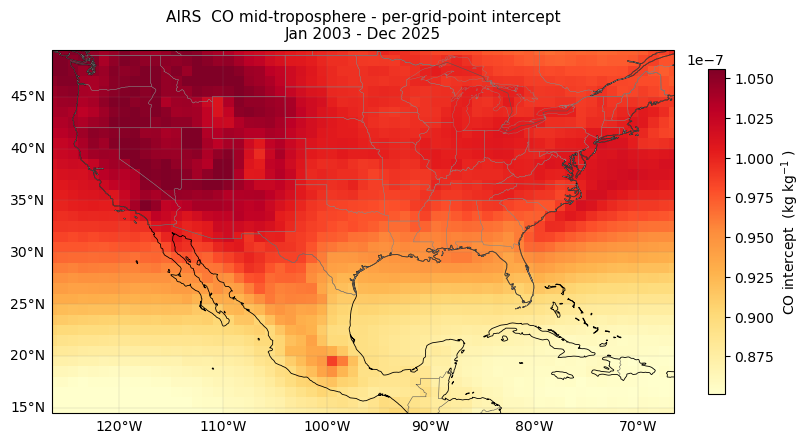

Saved -> ../Figures\spatial_co_trend_intercept_2003_2025.png


In [21]:
# Per-pixel slope map from the single fit.
import cartopy.crs as ccrs
import cartopy.feature as cfeature

slope = pixel_intercept

print(f"Per-pixel slope grid : {slope.shape}  (lat x lon)")
print(f"Slope range          : {np.nanmin(slope):.3e} - {np.nanmax(slope):.3e}  kg/kg/yr")
print(f"Domain-mean slope    : {np.nanmean(slope):.3e}  kg/kg/yr")

# Plot.
ext = [float(lons.min()), float(lons.max()),
       float(lats.min()), float(lats.max())]

vmax_s = np.nanpercentile(np.abs(slope), 98)
vmin_s = np.nanpercentile(slope, 2)


fig_s, ax_s = plt.subplots(
    figsize=(8, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
   
)
ax_s.set_extent(ext, crs=ccrs.PlateCarree())
ax_s.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="k")
ax_s.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor="#555")
ax_s.add_feature(cfeature.STATES,    linewidth=0.25, edgecolor="#888")

pcm = ax_s.pcolormesh(
    lons, lats, slope,
    transform=ccrs.PlateCarree(),
    cmap="YlOrRd", vmin=vmin_s, vmax=vmax_s, shading="auto",
)
cb = fig_s.colorbar(pcm, ax=ax_s, orientation="vertical", shrink=0.55, pad=0.02)
cb.set_label("CO intercept  (kg kg$^{-1}$ )", fontsize=10)

gl = ax_s.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4)
gl.top_labels = gl.right_labels = False

ax_s.set_title(
    "AIRS  CO mid-troposphere - per-grid-point intercept\n"
    f"{months[0].strftime('%b %Y')} - {months[-1].strftime('%b %Y')}",
    fontsize=11, pad=8,
)

out_s = os.path.join(OUT_DIR, "spatial_co_trend_intercept_2003_2025.png")
fig_s.savefig(out_s, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_s)

## Mean slope and intercept 

In [14]:
# Mean-series trend from the per-pixel fit: a, b are the spatial mean of the
# pixel coefficients; uncertainties / R2 / RMSE from the mean-series residual.
a = np.nanmean(pixel_slope)
b = np.nanmean(pixel_intercept)

fit_line = b + a * yr                 # straight line 
resid    = ts_co - fit_line
n        = len(yr)

ss_res = np.sum(resid**2)
ss_tot = np.sum((ts_co - ts_co.mean())**2)
r2     = 1 - ss_res / ss_tot
rmse   = np.sqrt(ss_res / n)

# OLS parameter errors from the residual (unbiased, n-2).
Sxx   = np.sum((yr - yr.mean())**2)
s2    = ss_res / (n - 2)
a_err = np.sqrt(s2 / Sxx)
b_err = np.sqrt(s2 * (1 / n + yr.mean()**2 / Sxx))

print(f"Linear regression  y = a*x + b   (x in years since {ts_dates[0].date()})")
print(f"  slope a     = {a:.6e}  +/- {a_err:.2e}  kg/kg per year")
print(f"  intercept b = {b:.6e}  +/- {b_err:.2e}  kg/kg")
print(f"  R^2         = {r2:.4f}")
print(f"  RMSE        = {rmse:.4e}  kg/kg")
print(f"  N points    = {n}")

Linear regression  y = a*x + b   (x in years since 2003-01-01)
  slope a     = -4.734322e-10  +/- 7.57e-11  kg/kg per year
  intercept b = 9.575683e-08  +/- 1.00e-09  kg/kg
  R^2         = 0.1249
  RMSE        = 8.3213e-09  kg/kg
  N points    = 276


## Timeseries of the mean values with linear fit

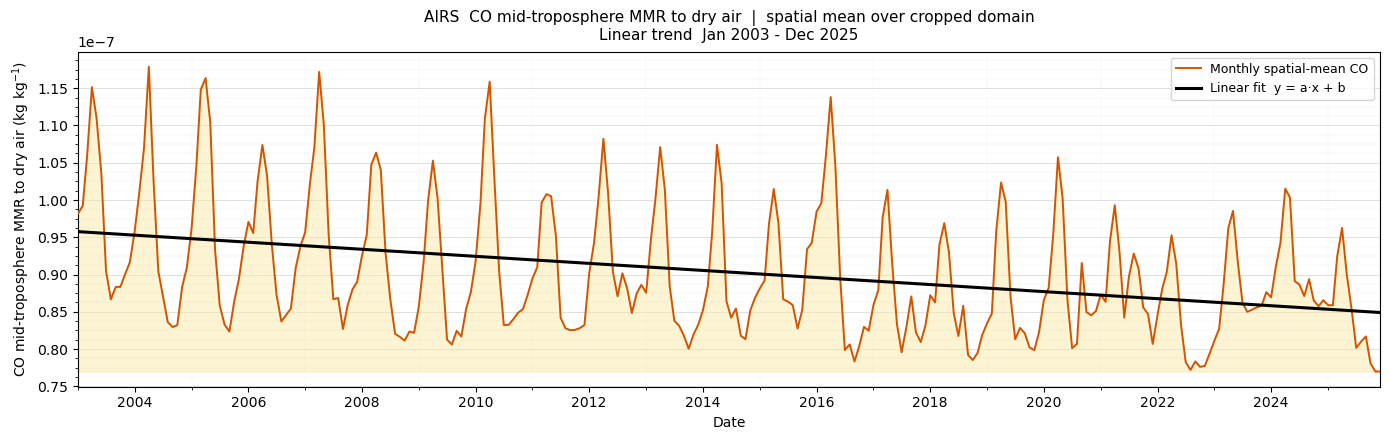

Saved -> ../Figures\timeseries_co_linear_trend_2003_2025.png


In [15]:
# Plot: monthly series + fitted regression line.
fig_ts, ax_ts = plt.subplots(figsize=(14, 4.5))

ax_ts.plot(ts_dates, ts_co, lw=1.4, color="#d35400", zorder=3,
           label="Monthly spatial-mean CO")
ax_ts.fill_between(ts_dates, ts_co, ts_co.min(),
                   alpha=0.45, color="#f9e79f", zorder=2)

ax_ts.plot(ts_dates, fit_line, lw=2.2, color="k", zorder=4,
           label="Linear fit  y = a·x + b")

ax_ts.legend(fontsize=9, loc="upper right")

ax_ts.set_title(
    f"AIRS  CO mid-troposphere MMR to dry air  |  spatial mean over cropped domain\n"
    f"Linear trend  {ts_dates[0].strftime('%b %Y')} - {ts_dates[-1].strftime('%b %Y')}",
    fontsize=11, pad=8,
)
ax_ts.set_ylabel("CO mid-troposphere MMR to dry air (kg kg$^{-1}$)", fontsize=10)
ax_ts.set_xlabel("Date", fontsize=10)

ax_ts.xaxis.set_major_locator(mdates.YearLocator(2))
ax_ts.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_ts.xaxis.set_minor_locator(mdates.YearLocator())
ax_ts.yaxis.set_minor_locator(AutoMinorLocator(4))
ax_ts.grid(axis="y", which="major", lw=0.5, alpha=0.55)
ax_ts.grid(axis="y", which="minor", lw=0.2, alpha=0.3)
ax_ts.grid(axis="x", which="minor", lw=0.2, alpha=0.25)
ax_ts.set_xlim(ts_dates[0], ts_dates[-1])

fig_ts.tight_layout()

out_ts = os.path.join(OUT_DIR, "timeseries_co_linear_trend_2003_2025.png")
fig_ts.savefig(out_ts, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_ts)

New timeseries by doing cos weighting and then fitting the line

In [17]:
# ----------------------------------------------------------------------
# Cosine-latitude-weighted spatial mean series and its OLS trend.
# `final_maps` : DataArray (time, lat, lon) of CO MMR  -- rename to match yours
# `yr`     : decimal years since ts_dates[0]
# ----------------------------------------------------------------------
lat_name = "lat" if "lat" in final_maps.dims else "latitude"
lon_name = "lon" if "lon" in final_maps.dims else "longitude"

# sqrt(cos) is for EOF variance weighting; for an area-mean use cos(lat) itself.
wgt = np.cos(np.deg2rad(final_maps[lat_name]))
wgt = wgt.broadcast_like(final_maps.isel(time=0))          # (lat, lon)

valid   = final_maps.notnull()                              # per-time NaN mask
w_field = wgt.where(valid)                              # zero-out missing pixels

ts_co_w = (final_maps * w_field).sum(dim=(lat_name, lon_name), skipna=True) \
          / w_field.sum(dim=(lat_name, lon_name), skipna=True)
ts_co_w = ts_co_w.values

# ---- OLS fit on the weighted mean series -----------------------------
aw, bw = np.polyfit(yr, ts_co_w, 1)

fit_line_w = bw + aw * yr
resid_w    = ts_co_w - fit_line_w
n          = len(yr)

ss_res_w = np.sum(resid_w**2)
ss_tot_w = np.sum((ts_co_w - ts_co_w.mean())**2)
r2_w     = 1 - ss_res_w / ss_tot_w
rmse_w   = np.sqrt(ss_res_w / n)

Sxx    = np.sum((yr - yr.mean())**2)
s2_w   = ss_res_w / (n - 2)
aw_err = np.sqrt(s2_w / Sxx)
bw_err = np.sqrt(s2_w * (1 / n + yr.mean()**2 / Sxx))

print(f"Cos(lat)-weighted mean series   y = a*x + b   (x in years since {ts_dates[0].date()})")
print(f"  slope a     = {aw:.6e}  +/- {aw_err:.2e}  kg/kg per year")
print(f"  intercept b = {bw:.6e}  +/- {bw_err:.2e}  kg/kg")
print(f"  R^2         = {r2_w:.4f}")
print(f"  RMSE        = {rmse_w:.4e}  kg/kg")
print(f"  N points    = {n}")
print(f"  slope diff vs unweighted = {100*(aw - a)/abs(a):+.2f} %")

Cos(lat)-weighted mean series   y = a*x + b   (x in years since 2003-01-01)
  slope a     = -4.627145e-10  +/- 7.50e-11  kg/kg per year
  intercept b = 9.514277e-08  +/- 9.94e-10  kg/kg
  R^2         = 0.1219
  RMSE        = 8.2460e-09  kg/kg
  N points    = 276
  slope diff vs unweighted = +2.26 %


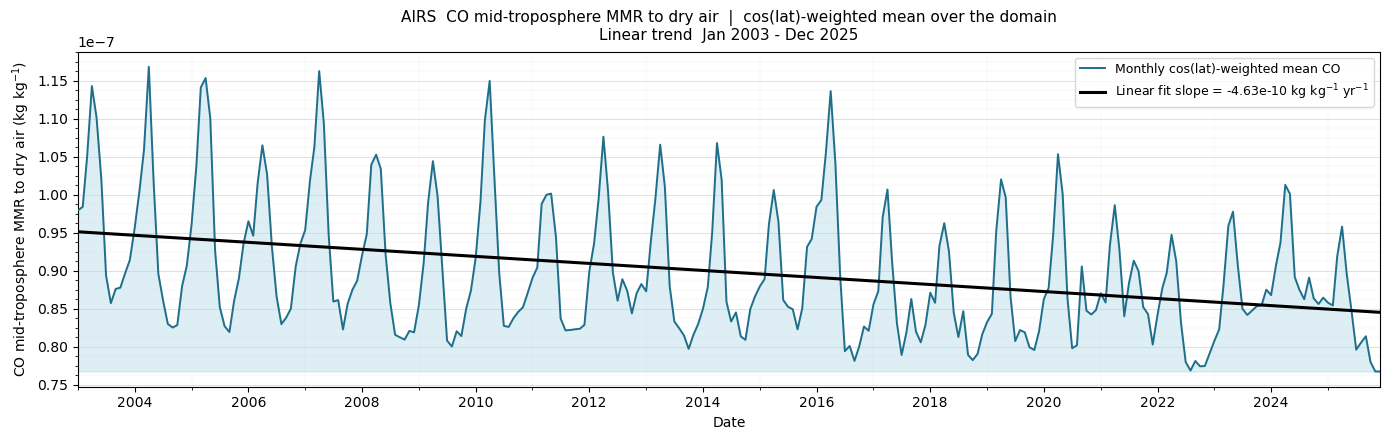

Saved -> ../Figures\timeseries_co_coslat_linear_trend_2003_2025.png


In [22]:
# Plot: cos-weighted monthly series + fitted regression line.
fig_w, ax_w = plt.subplots(figsize=(14, 4.5))

ax_w.plot(ts_dates, ts_co_w, lw=1.4, color="#1f6f8b", zorder=3,
          label="Monthly cos(lat)-weighted mean CO")
ax_w.fill_between(ts_dates, ts_co_w, ts_co_w.min(),
                  alpha=0.40, color="#aed6e6", zorder=2)

ax_w.plot(ts_dates, fit_line_w, lw=2.2, color="k", zorder=4,
          label=f"Linear fit slope = {aw:.2e} kg kg$^{{-1}}$ yr$^{{-1}}$")

ax_w.legend(fontsize=9, loc="upper right")

ax_w.set_title(
    f"AIRS  CO mid-troposphere MMR to dry air  |  cos(lat)-weighted mean over the domain\n"
    f"Linear trend  {ts_dates[0].strftime('%b %Y')} - {ts_dates[-1].strftime('%b %Y')}",
    fontsize=11, pad=8,
)
ax_w.set_ylabel("CO mid-troposphere MMR to dry air (kg kg$^{-1}$)", fontsize=10)
ax_w.set_xlabel("Date", fontsize=10)

ax_w.xaxis.set_major_locator(mdates.YearLocator(2))
ax_w.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_w.xaxis.set_minor_locator(mdates.YearLocator())
ax_w.yaxis.set_minor_locator(AutoMinorLocator(4))
ax_w.grid(axis="y", which="major", lw=0.5, alpha=0.55)
ax_w.grid(axis="y", which="minor", lw=0.2, alpha=0.3)
ax_w.grid(axis="x", which="minor", lw=0.2, alpha=0.25)
ax_w.set_xlim(ts_dates[0], ts_dates[-1])

fig_w.tight_layout()

out_w = os.path.join(OUT_DIR, "timeseries_co_coslat_linear_trend_2003_2025.png")
fig_w.savefig(out_w, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_w)

## Subtracting the linear fit from data

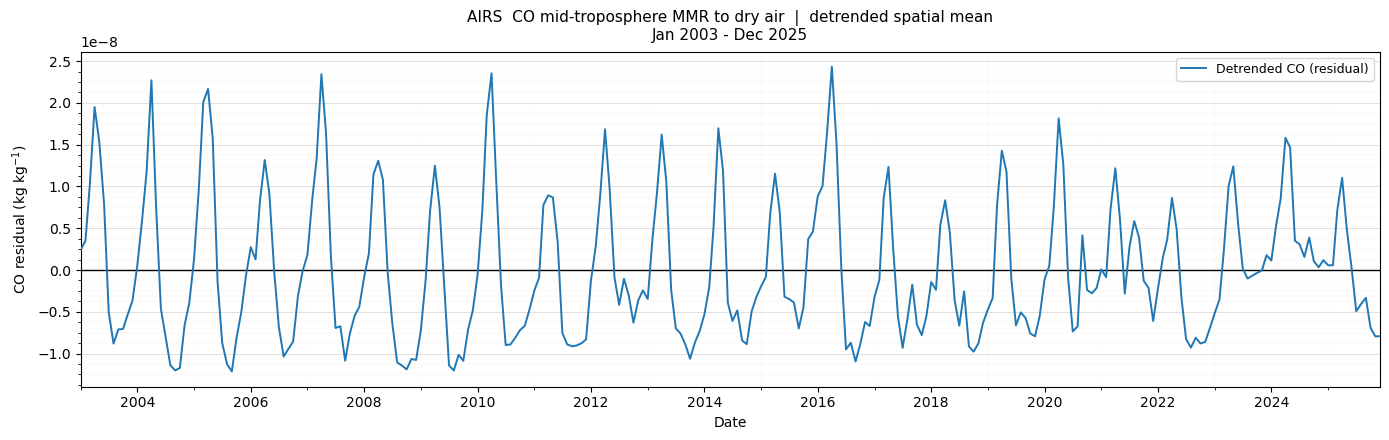

Saved -> ../Figures\timeseries_co_detrended_2003_2025.png


In [ ]:
# Detrended series = spatial mean of the per-pixel detrended field.
detrended = detr_field.mean(("lat", "lon")).values

fig_dt, ax_dt = plt.subplots(figsize=(14, 4.5))
ax_dt.axhline(0, color="k", lw=1, zorder=2)
ax_dt.plot(ts_dates, detrended, lw=1.4, color="#1f77b4", zorder=3,
           label="Detrended CO (residual)")

ax_dt.legend(fontsize=9, loc="upper right")
ax_dt.set_title(
    f"AIRS  CO mid-troposphere MMR to dry air  |  detrended spatial mean\n"
    f"{ts_dates[0].strftime('%b %Y')} - {ts_dates[-1].strftime('%b %Y')}",
    fontsize=11, pad=8,
)
ax_dt.set_ylabel("CO residual (kg kg$^{-1}$)", fontsize=10)
ax_dt.set_xlabel("Date", fontsize=10)

ax_dt.xaxis.set_major_locator(mdates.YearLocator(2))
ax_dt.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_dt.xaxis.set_minor_locator(mdates.YearLocator())
ax_dt.yaxis.set_minor_locator(AutoMinorLocator(4))
ax_dt.grid(axis="y", which="major", lw=0.5, alpha=0.55)
ax_dt.grid(axis="y", which="minor", lw=0.2, alpha=0.3)
ax_dt.grid(axis="x", which="minor", lw=0.2, alpha=0.25)
ax_dt.set_xlim(ts_dates[0], ts_dates[-1])

fig_dt.tight_layout()
out_dt = os.path.join(OUT_DIR, "timeseries_co_detrended_2003_2025.png")
fig_dt.savefig(out_dt, dpi=150, bbox_inches="tight")
plt.show()
print("Saved ->", out_dt)

In [ ]:
# Temporal mean of the detrended data to check if it's zero
temporal_mean = np.mean(detrended)
temporal_std = np.std(detrended)

print(f"Temporal mean of detrended data: {temporal_mean:.4e} kg/kg")
print(f"Temporal std of detrended data:  {temporal_std:.4e} kg/kg")
print(f"Is temporal mean close to zero? {np.abs(temporal_mean) < 1e-15}")

Temporal mean of detrended data: -1.6783e-25 kg/kg
Temporal std of detrended data:  8.3213e-09 kg/kg
Is temporal mean close to zero? True
